参数的真实值: β0 = 0.500, β1 = 1.500
BFGS 估计的参数: β0 = 0.517, β1 = 1.467
IRLS 估计的参数: β0 = 0.517, β1 = 1.467
Newton 法估计的参数: β0 = 0.517, β1 = 1.467


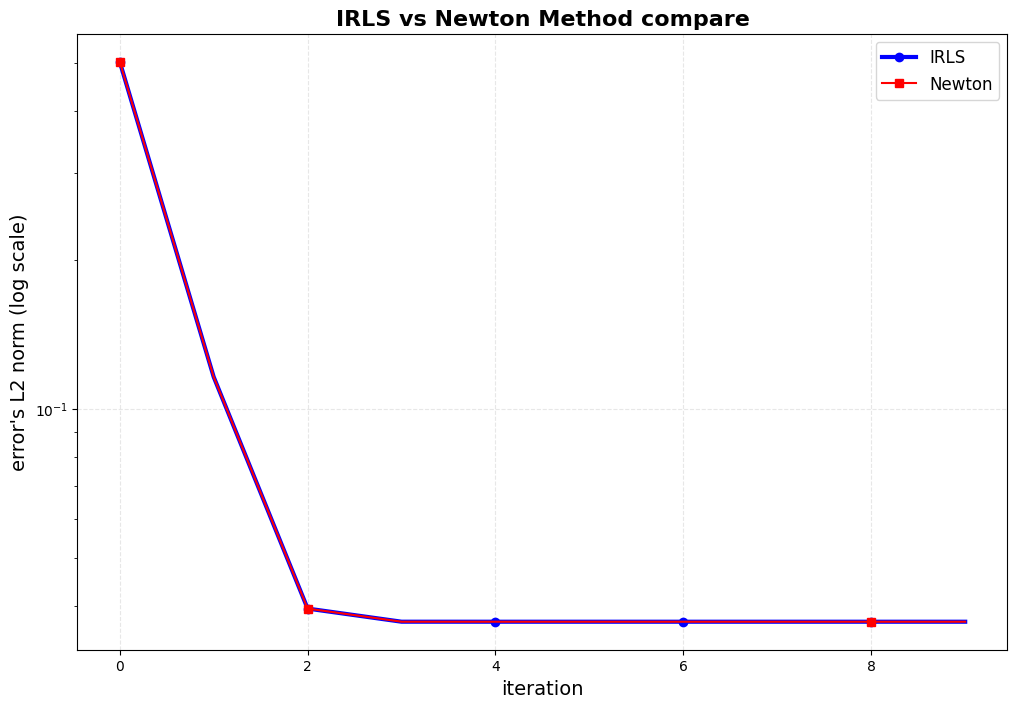

In [9]:
import warnings
warnings.filterwarnings('ignore')  # 忽略警告

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# plt.rcParams['font.sans-serif'] = ['SimHei']   # 设置中文字体
# plt.rcParams['axes.unicode_minus'] = False  

np.random.seed(42)

# ==================== 1. 生成数据 ====================
n = 10000  # 样本数量
max_iter = 10  # 最大迭代次数
z = np.random.randn(n)  # 生成一维协变量
true_beta0 = 0.5
true_beta1 = 1.5
beta_true = np.array([true_beta0, true_beta1])

linear_predictor = true_beta0 + true_beta1 * z
true_prob = 1 / (1 + np.exp(-linear_predictor))
y = np.random.binomial(1, true_prob)
Z = np.column_stack([np.ones(n), z])

# ==================== 2. 定义辅助函数 ====================
def sigmoid(x):
    """Sigmoid函数"""
    return 1 / (1 + np.exp(-x))

def compute_pi(beta, Z):
    """计算概率π = P(Y=1|Z)"""
    return sigmoid(Z @ beta)

def compute_log_likelihood(beta, Z, y):
    """计算对数似然函数值"""
    pi = compute_pi(beta, Z)
    # 避免log(0)的情况
    eps = 1e-15
    pi = np.clip(pi, eps, 1-eps)
    return np.sum(y * np.log(pi) + (1-y) * np.log(1-pi))

# ==================== 3. 用scipy的BFGS作为基准解 ====================
def neg_log_likelihood(beta):
    """负对数似然（用于最小化）"""
    return -compute_log_likelihood(beta, Z, y)

# 初始值
beta_init = np.array([0.0, 0.0])

# 使用BFGS优化找到MLE（作为基准）
res = minimize(neg_log_likelihood, beta_init, method='BFGS', options={'maxiter': max_iter, 'gtol': 1e-8})
beta_true_bfgs = res.x
print(f"参数的真实值: β0 = {true_beta0:.3f}, β1 = {true_beta1:.3f}")
print(f"BFGS 估计的参数: β0 = {beta_true_bfgs [0]:.3f}, β1 = {beta_true_bfgs [1]:.3f}")

# ==================== 4. 实现IRLS方法（添加扰动以区分）====================
def IRLS(Z, y, max_iter=100, tol=1e-8, perturb=1e-5):
    """迭代再加权最小二乘（添加微小扰动以区分）"""
    beta = beta_init.copy() + perturb  # 添加微小扰动
    errors_irls = []
    
    for t in range(max_iter):
        pi = compute_pi(beta, Z)         # 计算当前π和W        
        pi_clipped = np.clip(pi, 1e-10, 1-1e-10) # 防止权重为0
        W = np.diag(pi_clipped * (1 - pi_clipped))

        e = y - pi
        
        try:   # 使用伪逆避免奇异
            W_inv = np.linalg.inv(W)
        except np.linalg.LinAlgError:
            W_inv = np.linalg.pinv(W)
        
        working_response = Z @ beta + W_inv @ e        
        
        ZTW = Z.T @ W    # 更新β: 加权最小二乘
        
        try:   # 使用更稳定的求解方法
            beta_new = np.linalg.solve(ZTW @ Z, ZTW @ working_response)
        except np.linalg.LinAlgError:
            beta_new = np.linalg.lstsq(ZTW @ Z, ZTW @ working_response, rcond=None)[0]        
        
        error = np.linalg.norm(beta_new - beta_true)  # 计算与真实参数的误差
        errors_irls.append(error)        
        
        if error < tol:   # 检查收敛
            break
            
        beta = beta_new
    
    return beta, errors_irls

# ==================== 5. 实现Newton法 ====================
def newton_method(Z, y, max_iter=100, tol=1e-8):
    """Newton法"""
    beta = beta_init.copy()
    errors_newton = []
    
    for t in range(max_iter):        
        pi = compute_pi(beta, Z)    # 计算当前π和W        
        pi_clipped = np.clip(pi, 1e-10, 1-1e-10)    # 防止权重为0
        W = np.diag(pi_clipped * (1 - pi_clipped))       
        
        score = Z.T @ (y - pi)   # 计算得分函数（梯度）和Hessian 
        hessian = -Z.T @ W @ Z  
        
        # Newton更新
        try:
            delta = np.linalg.solve(hessian, score)
        except np.linalg.LinAlgError:
            delta = np.linalg.lstsq(hessian, score, rcond=None)[0]
        
        beta_new = beta - delta
        
        # 计算与真实参数的误差
        error = np.linalg.norm(beta_new - beta_true)
        errors_newton.append(error)

        if error < tol:  # 检查收敛
            break
            
        beta = beta_new
    
    return beta, errors_newton

# ==================== 6. 运行两种方法 ====================
beta_irls, errors_irls = IRLS(Z, y, max_iter=max_iter, perturb=0.001)  # 添加微小扰动
beta_newton, errors_newton = newton_method(Z, y, max_iter=max_iter)

print(f"IRLS 估计的参数: β0 = {beta_irls[0]:.3f}, β1 = {beta_irls[1]:.3f}")
print(f"Newton 法估计的参数: β0 = {beta_newton[0]:.3f}, β1 = {beta_newton[1]:.3f}")


# ==================== 7. 绘制误差比较图 ====================
plt.figure(figsize=(12, 8))
plt.plot(errors_irls, 'b-', linewidth=3, marker='o', markersize=6, markevery=2, label='IRLS')
plt.plot(errors_newton, 'r-', linewidth=1.5, marker='s', markersize=6, markevery=0.5, label='Newton')

plt.yscale('log')  # 对数坐标
plt.xlabel('iteration', fontsize=14)
plt.ylabel("error's L2 norm (log scale)", fontsize=14)
plt.title('IRLS vs Newton Method compare', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right')


In [ ]:
len(errors_newton),max_iter

(6, 100)